In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_titles.csv')

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.iloc[:, 7:]

,release_year,rating,duration,listed_in,description
0,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...
8802,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [15]:
df.shape

(8807, 12)

This dataset has 8807 rows and 12 columns

<Axes: >

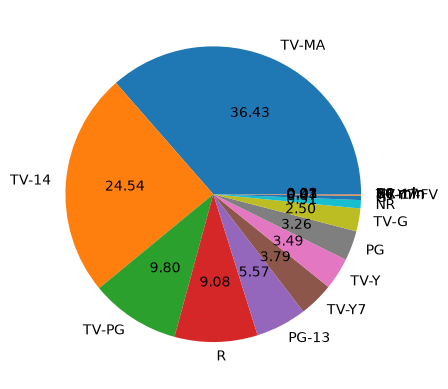

In [17]:
df['rating'].value_counts().plot(kind='pie', autopct='%.2f')

<Axes: xlabel='rating', ylabel='count'>

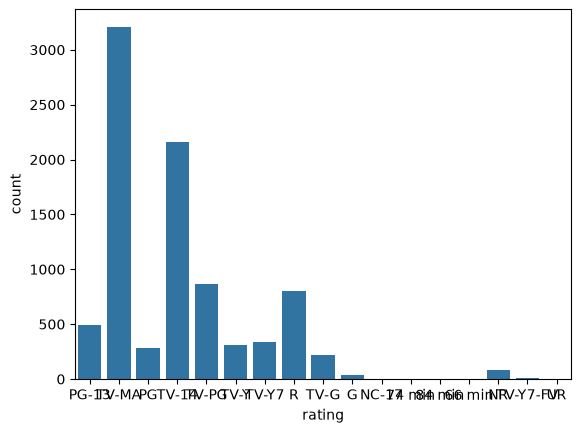

In [ ]:
sns.countplot(data=df, x='rating')    #Countplot

Which country produces the most tv-shows?

<Axes: xlabel='count', ylabel='country'>

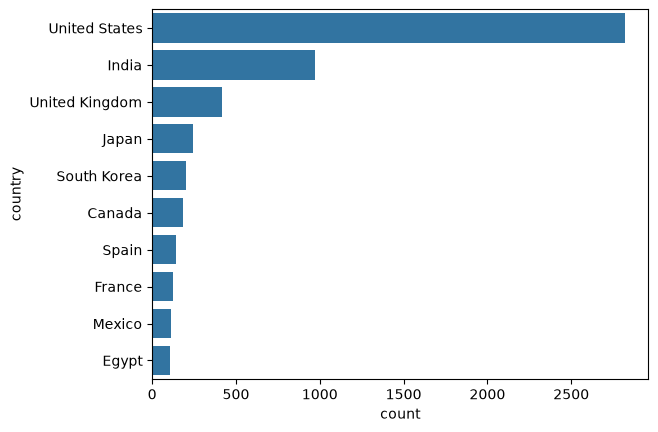

In [32]:
sns.countplot(
    data=df,
    y="country",
    order=df["country"].value_counts().head(10).index
)

These are the top 10 countries appear the most

In [39]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

### Observation

- Netflix's catalog contains 6,131 Movies and 2,676 TV Shows.
- Movies account for approximately **69.6%** of the catalog.
- TV Shows account for approximately **30.4%**.
- This indicates Netflix's catalog is primarily movie-oriented.

Which ratings are most common?

In [46]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='rating'>

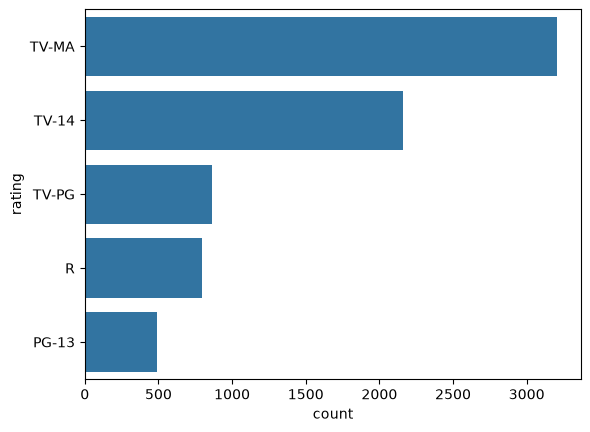

In [45]:
sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().head(5).index
)

TV-MA is the most common rating 

Which year has the most release?

<Axes: xlabel='release_year'>

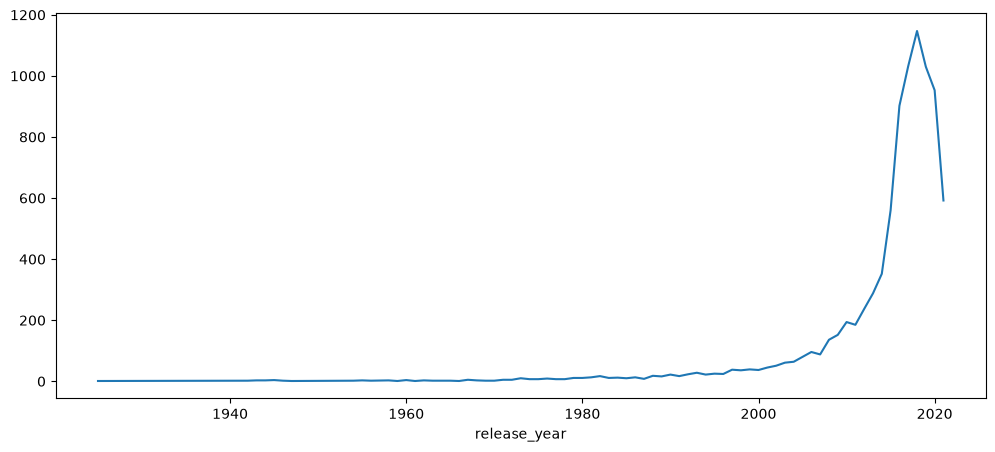

In [5]:
year_counts = df["release_year"].value_counts().sort_index()

year_counts.plot(kind="line", figsize=(12,5))

What are the 10 most common genres?


In [8]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

In [10]:
genres.value_counts().head(10)


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

<Axes: ylabel='listed_in'>

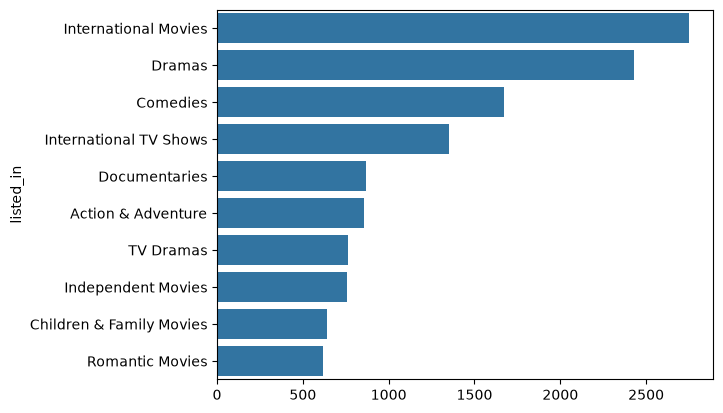

In [11]:
top10 = genres.value_counts().head(10)

sns.barplot(
    x=top10.values,
    y=top10.index
)

What percentage of catalog is movies?

<Axes: title={'center': 'Total percentage of movies and tv-shows'}>

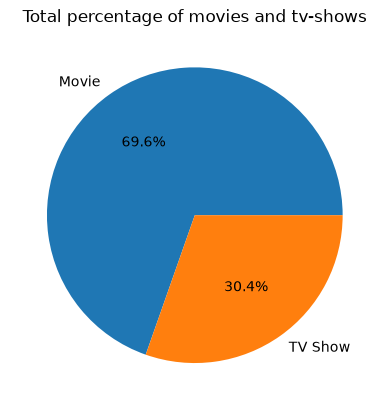

In [14]:
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel="",
    title="Total percentage of movies and tv-shows"
)

### Observation

- Movies account for **69.6%** of the Netflix catalog.
- TV Shows account for **30.4%**.
- Netflix's catalog is primarily movie-focused, with roughly 7 out of every 10 titles being movies.

Which ratings are common for TV Shows?

In [15]:
tv_shows = df[df["type"] == "TV Show"]

In [17]:
tv_shows['rating'].value_counts()

rating
TV-MA       1145
TV-14        733
TV-PG        323
TV-Y7        195
TV-Y         176
TV-G          94
NR             5
R              2
TV-Y7-FV       1
Name: count, dtype: int64

<Axes: xlabel='rating', ylabel='count'>

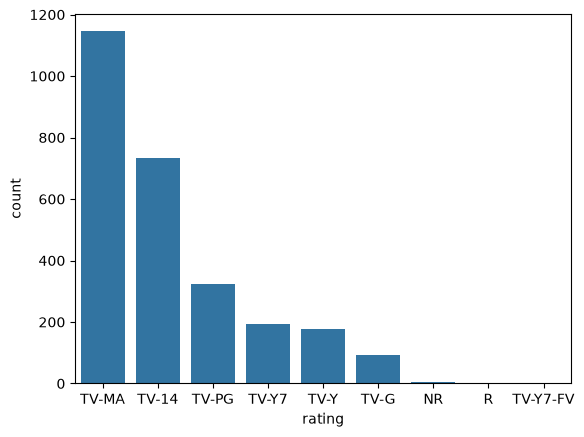

In [19]:
sns.countplot(
    data=tv_shows,
    x="rating",
    order=tv_shows["rating"].value_counts().index
)

### Observation

- The countplot shows that TV-MA is the most common rating for TV Shows.
- This suggests that Netflix’s TV Show catalog is mostly aimed at mature audiences.
- TV-14 and TV-PG also appear frequently, while ratings for younger audiences are less common.